# Enunciado

Para realizar esta atividade, carregue o dataset IEEE-CIS Fraud Detection. Em seguida, faça uma análise exploratória dos dados para entender as características das transações, como distribuições, correlações e possíveis outliers. Use gráficos e estatísticas descritivas para apoiar sua análise.


Depois, prepare os dados para o treinamento da rede neural LSTM. Isso pode incluir o tratamento de valores ausentes, normalização e a criação de sequências temporais, conforme necessário para o modelo LSTM. Em seguida, defina a arquitetura da rede LSTM, escolhendo o número de camadas, neurônios, e outros hiperparâmetros relevantes.


Treine o modelo utilizando um conjunto de treinamento e valide-o utilizando um conjunto de teste. Aplique métricas como precisão, recall, F1-score e AUC-ROC para avaliar o desempenho do modelo. Durante o treinamento, observe a curva de aprendizado para identificar sinais de overfitting ou underfitting.


Após treinar o modelo, analise os resultados. Compare o desempenho nas diferentes fases do treinamento e identifique qualquer possível overfitting ou outros problemas de ajuste. Discuta as estratégias que você utilizou para melhorar a performance do modelo e os insights que obteve durante o processo.


Por fim, documente todas as etapas realizadas, incluindo a preparação dos dados, a definição da arquitetura do modelo, o treinamento, a validação, e a análise dos resultados.


Entregue o link do caderno `.ipynb` em um repositório GitHub.

## Importação

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from imblearn.over_sampling import SMOTE
!pip install kaggle

## Carregando os dados

In [2]:
df_trans = pd.read_csv('train_transaction.csv')
df_id = pd.read_csv('train_identity.csv')

In [3]:
df = df_trans.merge(df_id, on='TransactionID', how='left')

## Análise exploratória

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB
None
isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


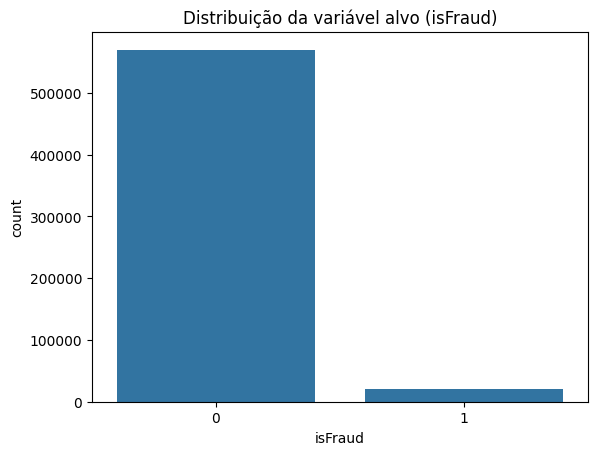

In [4]:
print(df.info())
print(df['isFraud'].value_counts(normalize=True))
sns.countplot(x='isFraud', data=df)
plt.title('Distribuição da variável alvo (isFraud)')
plt.show()

In [5]:
print(df.describe())

       TransactionID        isFraud  TransactionDT  TransactionAmt  \
count   5.905400e+05  590540.000000   5.905400e+05   590540.000000   
mean    3.282270e+06       0.034990   7.372311e+06      135.027176   
std     1.704744e+05       0.183755   4.617224e+06      239.162522   
min     2.987000e+06       0.000000   8.640000e+04        0.251000   
25%     3.134635e+06       0.000000   3.027058e+06       43.321000   
50%     3.282270e+06       0.000000   7.306528e+06       68.769000   
75%     3.429904e+06       0.000000   1.124662e+07      125.000000   
max     3.577539e+06       1.000000   1.581113e+07    31937.391000   

               card1          card2          card3          card5  \
count  590540.000000  581607.000000  588975.000000  586281.000000   
mean     9898.734658     362.555488     153.194925     199.278897   
std      4901.170153     157.793246      11.336444      41.244453   
min      1000.000000     100.000000     100.000000     100.000000   
25%      6019.000000    

## Pré processamento

### Plot distribuições de variáveis numéricas selecionadas

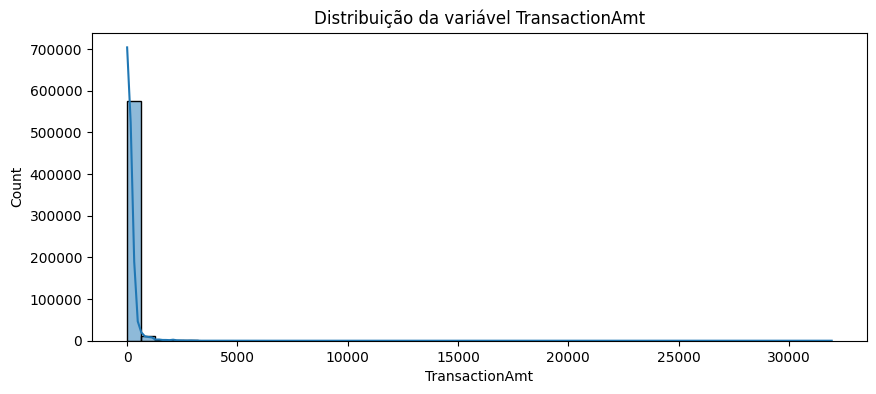

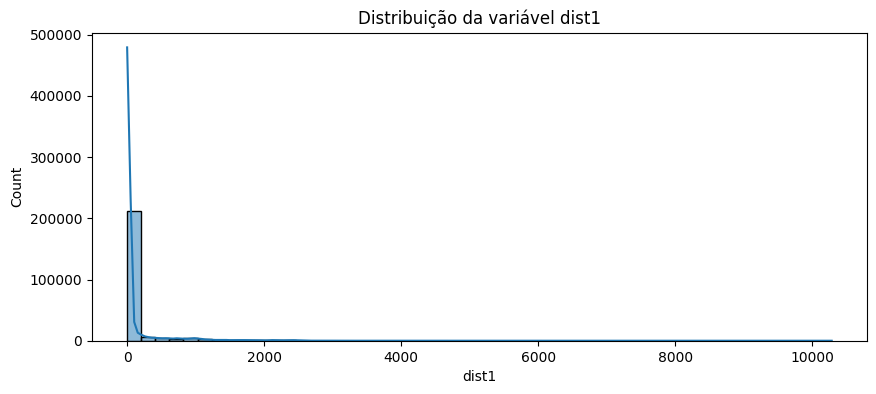

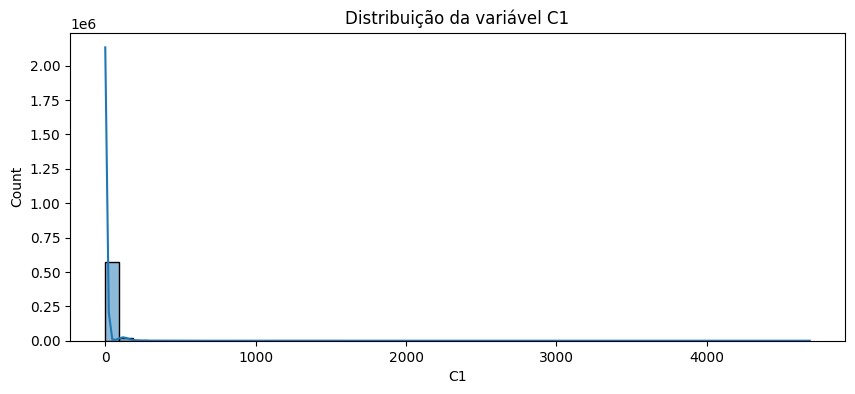

In [6]:
cols_to_plot = ['TransactionAmt', 'dist1', 'C1']
for col in cols_to_plot:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col].dropna(), bins=50, kde=True)
    plt.title(f'Distribuição da variável {col}')
    plt.show()

### Checagem e tratamento de valores ausentes

In [7]:
missing = df.isnull().mean() * 100
print(missing[missing > 0])
df.fillna(-1, inplace=True)

card2          1.512683
card3          0.265012
card4          0.267044
card5          0.721204
card6          0.266028
                ...    
id_36         76.126088
id_37         76.126088
id_38         76.126088
DeviceType    76.155722
DeviceInfo    79.905510
Length: 414, dtype: float64


### Normalização das variáveis numéricas (excluindo ids e target)

In [8]:
num_features = df.select_dtypes(include=['float64', 'int64']).columns.drop(['TransactionID', 'isFraud'])
scaler = StandardScaler()
df[num_features] = scaler.fit_transform(df[num_features])

### Preparação dos dados para o modelo LSTM

In [9]:
X = df[num_features].values
y = df['isFraud'].values

### Balanceamento com SMOTE para a classe minoritária

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
# Reduzindo o tamanho da base para treino

X_sample, _, y_sample, _ = train_test_split(X, y, test_size=0.8, stratify=y, random_state=42)

In [12]:
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_sample, y_sample)

## Treinamento

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

In [14]:
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

### Definição da arquitetura LSTM

In [15]:
model = Sequential()
model.add(LSTM(units=64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │       119,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,361 (466.25 KB)

 Trainable params: 119,361 (466.25 KB)

 Non-trainable params: 0 (0.00 B)

None


In [16]:
history = model.fit(X_train, y_train, epochs=10, batch_size=128, validation_split=0.2)

Epoch 1/10
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7536 - loss: 0.4912 - val_accuracy: 0.8095 - val_loss: 0.4066
Epoch 2/10
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.8114 - loss: 0.4029 - val_accuracy: 0.8398 - val_loss: 0.3556
Epoch 3/10
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.8342 - loss: 0.3596 - val_accuracy: 0.8593 - val_loss: 0.3164
Epoch 4/10
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8509 - loss: 0.3276 - val_accuracy: 0.8749 - val_loss: 0.2903
Epoch 5/10
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8641 - loss: 0.3026 - val_accuracy: 0.8833 - val_loss: 0.2682
Epoch 6/10
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8737 - loss: 0.2845 - val_accuracy: 0.8852 - val_loss: 0.2621
Epoch 7/10
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8798 - loss: 0.2676 - val_accuracy: 0.8979 - val_loss: 0.2400
Epoch 8/10
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8859 - l

### Avaliação do modelo

In [17]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print('AUC ROC:', roc_auc_score(y_test, y_pred_prob))

1425/1425 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
              precision    recall  f1-score   support

           0       0.92      0.90      0.91     22694
           1       0.91      0.92      0.91     22896

    accuracy                           0.91     45590
   macro avg       0.91      0.91      0.91     45590
weighted avg       0.91      0.91      0.91     45590

AUC ROC: 0.9743026941337295


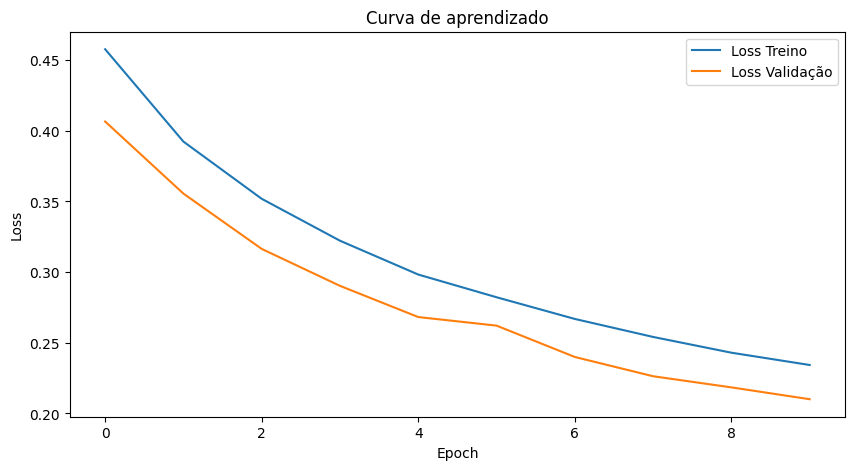

In [18]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Loss Treino')
plt.plot(history.history['val_loss'], label='Loss Validação')
plt.title('Curva de aprendizado')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

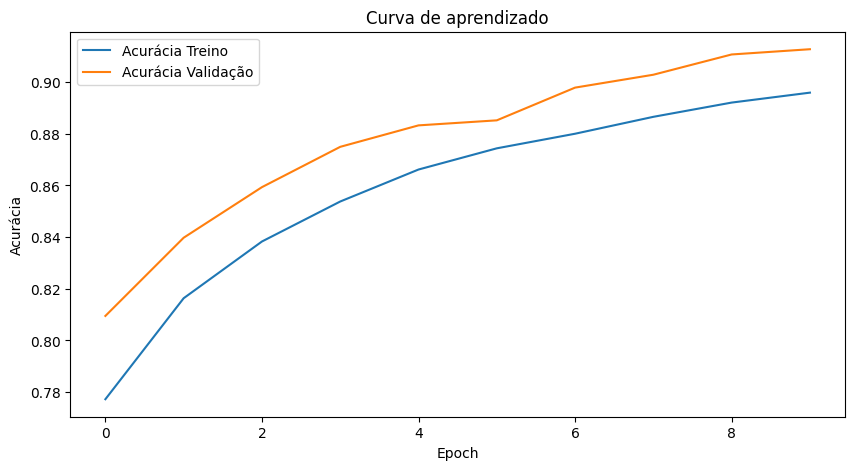

In [19]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Acurácia Treino')
plt.plot(history.history['val_accuracy'], label='Acurácia Validação')
plt.title('Curva de aprendizado')
plt.xlabel('Epoch')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

## Conclusão

A análise do dataset IEEE-CIS Fraud Detection com uma abordagem LSTM demonstrou bons resultados para a detecção de fraudes, mesmo em um contexto de dados originalmente desbalanceados e dimensionalidade alta.

### Preparação e pré-processamento dos dados

- Foi realizado o merge dos arquivos de transações e identidades, preenchimento de valores ausentes e normalização das variáveis numéricas
- Para o desbalanceamento, uma amostra foi balanceada usando SMOTE antes de treinar o modelo, evitando erros de memória comuns com dados massivos
- As features foram organizadas em tensores compatíveis com a entrada LSTM, ainda que o dataset não possua um componente temporal explícito (cada transação foi considerada como uma sequência independente de 1 timestep).

### Arquitetura do modelo LSTM

O modelo utilizado teve uma arquitetura bastante direta:
- 1 camada LSTM com 64 neurônios,
- Dropout de 0.3 para regularização,
- 1 camada densa final com ativação sigmoide para classificação binária.
- Total de ~119 mil parâmetros treináveis, adequada para demonstrar aprendizado sem sobrecarregar a infraestrutura.

### Resultado do treinamento e avaliação

- O treinamento ocorreu de forma estável, acompanhando as curvas de acurácia e perda fornecidas:
    - A acurácia de validação se manteve acima da acurácia de treino em todas as épocas e próximo de 0.92 na última época, sem indícios graves de overfitting (as curvas de loss também se mantiveram próximas e caindo)
- As métricas de avaliação no conjunto de teste:
    - **Acurácia**: 0.91
    - **Precision** (precisão): 0.92 para classe 0 e 0.91 para classe 1
    - **Recall**: 0.90 para classe 0 e 0.92 para classe 1
    - **F1-score**: aproximadamente 0.91 para ambas as classes
    - **AUC ROC**: 0.97, indicando uma alta separabilidade do modelo.

### Considerações sobre o desempenho e o processo

- O desempenho acima de 90% nas principais métricas indica que o modelo aprendeu padrões eficazes para separar fraudes de transações legítimas, mesmo após balanceamento com SMOTE.
- O uso de uma arquitetura enxuta de LSTM, com regularização via dropout e validação cruzada, ajudou a evitar overfitting, como pode ser visto na proximidade das curvas de validação e treino.
- A estratégia de subamostragem para aplicação do SMOTE foi importante para evitar quebra de RAM, mostrando que, para bases muito grandes, trabalhar com uma amostra estatisticamente representativa pode trazer benefícios práticos sem grandes perdas de generalização.
- O valor elevado do AUC ROC destaca que o modelo consegue discriminar entre transações fraudulentas e normais com alta robustez, atributo importante em aplicações reais, onde os custos de fraude são altos.

### Estratégias utilizadas para aumento de performance

- Amostragem estratificada antes do oversampling sintético.
- Padronização das features numéricas.
- Camada de dropout para reduzir overfitting.
- Monitoramento das curvas de aprendizado e validação para ajustes do número de épocas.
- Métricas apropriadas para dados desbalanceados, priorizando F1-score e AUC ROC em relação à acurácia simples.

### Insights e recomendações finais

- Para um ambiente produtivo, valeria a pena aprofundar a engenharia de features, utilizar maiores janelas temporais (quando houver dados históricos de clientes), avaliar LSTM empilhados e adicionar validação cruzada estratificada.
- O pipeline documentado é flexível e sua aplicação pode ser adaptada para outras bases de detecção de anomalias com perfis semelhantes de desbalanceamento.

O experimento ilustra bem a viabilidade do uso de LSTM para detecção de fraude em dados tabulares, desde que haja preprocessamento adequado e controle do balanceamento dos dados durante o treinamento.
